# Workflow:
1. Acquisizione dati
2. Preprocessamento
3. Estrazione feature
## 4. **Addestramento**
5. Integrazione

> Le celle di codice sottostanti non vengono modificate nella loro logica di lettura JSON/Parquet/pkl. Le celle Markdown aggiunte mappano ogni blocco al passo del workflow corrispondente e includono una breve legenda dei termini mostrati nei grafici.

In [1]:
import sys
sys.path.append("../../src")
from phm_america_2024.common.path_service_common import find_project_root
import duckdb
con = duckdb.connect()
import numpy as np
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib  # Libreria standard per la deserializzazione dei modelli ML
from scipy.stats import norm
import json
import ast
import pandas as pd
import joblib
import pickle
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

from IPython.display import display, Markdown # Importante per renderizzare l'analisi


In [2]:
# 1. Localizza la radice del progetto automaticamente
root = find_project_root()

# 2. Definisci il percorso verso la cartella di output (la base dei 'runs')
# l'ultima esecuzione o una specifica
run_id = "completo" # O l'ID che sto analizzando
base_run_dir = root / "outputs" / "runs" / "regression" / "phm2024" / run_id

# Definire il percorso di "base fase" per evitare hardcode in tutto il notebook
base_phase_path = base_run_dir / "phase4_data_modeling"

## 4. Addestramento — Selezione dell'Algoritmo

Configurazione architetturale del modello scelto per la regressione probabilistica del margine di coppia.

In [3]:
# --------------- SELEZIONE DEI DATI - step_4_1_algorithm_selection

Cosa fa davvero NGBoost:

Il modello non produce un solo numero per trq_margin, ma una distribuzione gaussiana completa: media (μ) e deviazione standard (σ). Per ottenere questo, NGBoost addestra due ensemble di alberi in parallelo, uno per μ e uno per σ, entrambi ottimizzati con la stessa LogScore (Negative Log-Likelihood) sotto distribuzione Normal. Il ramo σ è deliberatamente più semplice (meno alberi, alberi meno profondi, foglie con più campioni minimi) — pratica standard per evitare che la stima dell'incertezza diventi instabile o rumorosa.

In [ ]:
# 4.1.modeling.algo_setup_trace.json

**Termini nel grafico:**
- **NGBoost**: algoritmo di boosting che predice un'intera distribuzione di probabilità (non solo un valore puntuale), qui configurato con distribuzione Normale (media μ + deviazione standard σ).
- **Base Learner (Weak Learner)**: gli alberi decisionali semplici che compongono l'ensemble; qui limitati in profondità (`max_depth`) per evitare overfitting.
- **`n_estimators`**: numero di alberi sequenziali nell'ensemble.



4.1.modeling.algo_setup_trace.json non è la configurazione finale del modello — è il punto di partenza dichiarato prima della ricerca di iperparametri. È importante non presentarlo al professore come "la" configurazione, perché non lo è.

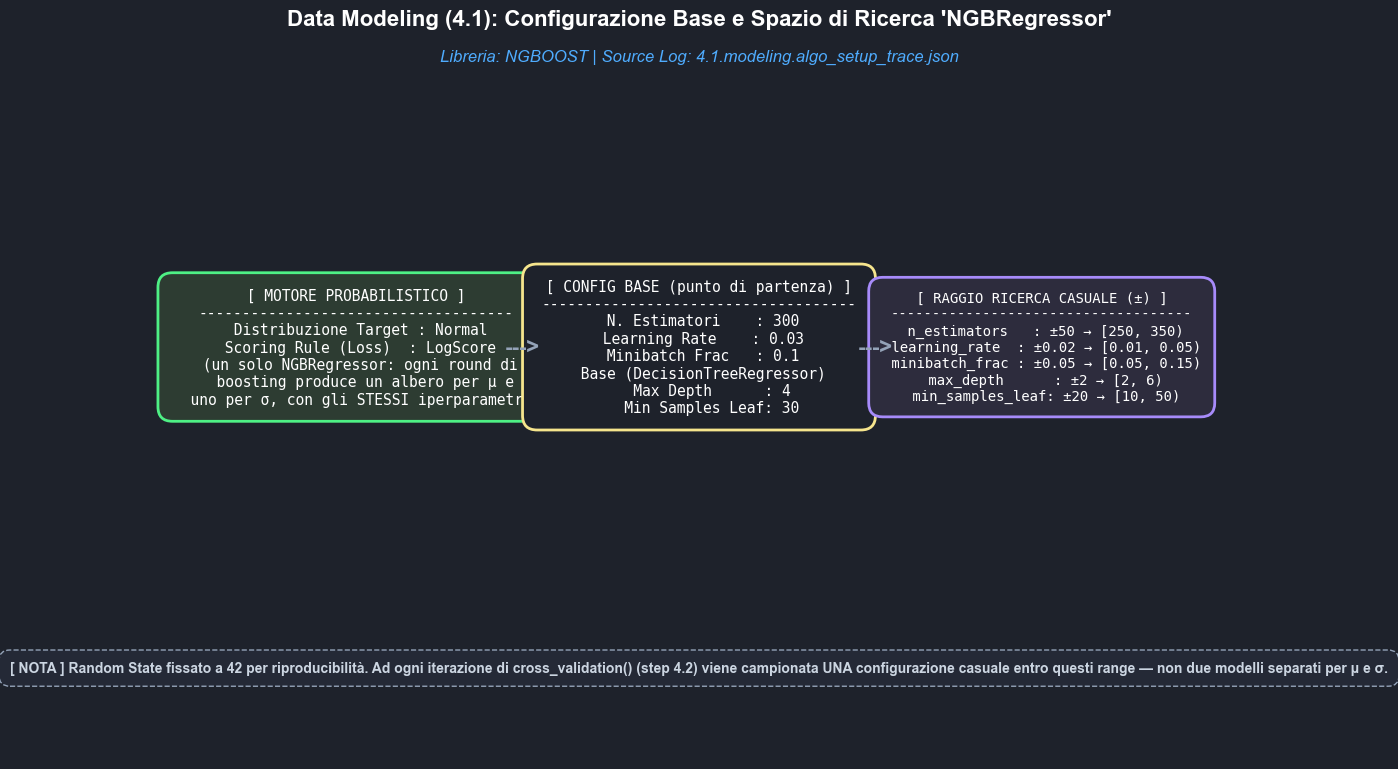


 ANALISI CONCLUSIVA: CONFIGURAZIONE ALGORITMO E SPAZIO DI RICERCA (4.1)
La scelta architetturale è ricaduta su 'NGBRegressor' della libreria 'ngboost'.
Questo artefatto è stato prodotto da 'single_probabilistic_architecture()'
in regression_algorithm_selector_model.py — confermato dalla presenza dei
campi '_uncertainty' a livello superiore, assenti nell'implementazione
alternativa trovata in regression_trainer_model.py (funzione morta/non
eseguita per questo step).

1. NATURA PROBABILISTICA:
   NGBoost addestra UN SOLO ensemble sotto la distribuzione 'Normal':
   ad ogni round di boosting vengono generati alberi che approssimano il
   gradiente naturale sia per μ (media) sia per σ (incertezza), condividendo
   gli stessi iperparametri di round.

2. CAMPI '_uncertainty':
   Rappresentano il raggio (±) del campionamento casuale usato dalla ricerca
   di iperparametri in step 4.2 — non un secondo modello. Il valore
   effettivamente selezionato da quella ricerca (best_config) e la verifi

In [6]:
# =============================================================================
# 1. FASE DI INPUT
# =============================================================================
filename_setup = "4.1.modeling.algo_setup_trace.json"
file_path_setup = base_phase_path / filename_setup

with open(file_path_setup, "r", encoding="utf-8") as f:
    setup_data = json.load(f)

# =============================================================================
# 2. FASE DI LOGICA
# =============================================================================
libreria = setup_data.get("library", "N/D")
stimatore = setup_data.get("estimator", "N/D")
config = setup_data.get("model_configured", {})

distribuzione = config.get("Dist", "N/D")
funzione_score = config.get("Score", "N/D")

num_estimatori = config.get("n_estimators", "N/D")
learning_rate = config.get("learning_rate", "N/D")
minibatch_frac = config.get("minibatch_frac", "N/D")

raggio_n_estimatori = config.get("n_estimators_uncertainty", "N/D")
raggio_learning_rate = config.get("learning_rate_uncertainty", "N/D")
raggio_minibatch_frac = config.get("minibatch_frac_uncertainty", "N/D")

base_learner = config.get("Base", {})
tipo_base = base_learner.get("type", "N/D")
profondita_max = base_learner.get("max_depth", "N/D")
foglie_minime = base_learner.get("min_samples_leaf", "N/D")

raggio_profondita_max = base_learner.get("max_depth_uncertainty", "N/D")
raggio_foglie_minime = base_learner.get("min_samples_leaf_uncertainty", "N/D")

def _range_str(base, raggio):
    if isinstance(base, (int, float)) and isinstance(raggio, (int, float)):
        return f"[{base - raggio:.4g}, {base + raggio:.4g})"
    return "N/D"

range_n_estimatori = _range_str(num_estimatori, raggio_n_estimatori)
range_learning_rate = _range_str(learning_rate, raggio_learning_rate)
range_minibatch_frac = _range_str(minibatch_frac, raggio_minibatch_frac)
range_profondita = _range_str(profondita_max, raggio_profondita_max)
range_foglie = _range_str(foglie_minime, raggio_foglie_minime)

# NOTA: questo script è volutamente autocontenuto — legge SOLO
# 4.1.modeling.algo_setup_trace.json. La verifica di quale configurazione
# concreta è stata selezionata dalla ricerca (best_config di 4.2) è
# logicamente una domanda downstream: appartiene allo script di analisi
# di 4.2, che consuma questa configurazione come proprio input, non il
# contrario. Questo evita una dipendenza in avanti (4.1 -> 4.2) che
# invertirebbe l'ordine naturale di esecuzione del notebook.

# =============================================================================
# 3. FASE DI DISEGNO
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(14, 8), facecolor='#1e222b')
ax.set_facecolor('#242936')
ax.axis('off')

fig.suptitle(f"Data Modeling (4.1): Configurazione Base e Spazio di Ricerca '{stimatore}'",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.895, f"Libreria: {libreria.upper()} | Source Log: {filename_setup}",
         fontsize=12, style='italic', color='#4facfe', ha='center')

props_prob = dict(boxstyle="round,pad=1", facecolor="#2d3c32", edgecolor="#4ef085", linewidth=2)
testo_prob = (
    f" [ MOTORE PROBABILISTICO ] \n"
    f"------------------------------------\n"
    f" Distribuzione Target : {distribuzione}\n"
    f" Scoring Rule (Loss)  : {funzione_score}\n"
    f" (un solo NGBRegressor: ogni round di\n"
    f"  boosting produce un albero per μ e\n"
    f"  uno per σ, con gli STESSI iperparametri)"
)
ax.text(0.18, 0.68, testo_prob, fontsize=10.5, family='monospace', color="white", va="center", ha="center", bbox=props_prob)

props_boost = dict(boxstyle="round,pad=1", facecolor="#1e222b", edgecolor="#f6e58d", linewidth=2)
testo_boost = (
    f" [ CONFIG BASE (punto di partenza) ] \n"
    f"------------------------------------\n"
    f" N. Estimatori    : {num_estimatori}\n"
    f" Learning Rate    : {learning_rate}\n"
    f" Minibatch Frac   : {minibatch_frac}\n"
    f" Base ({tipo_base})\n"
    f"   Max Depth      : {profondita_max}\n"
    f"   Min Samples Leaf: {foglie_minime}"
)
ax.text(0.50, 0.68, testo_boost, fontsize=10.5, family='monospace', color="white", va="center", ha="center", bbox=props_boost)

props_search = dict(boxstyle="round,pad=1", facecolor="#2d2c3d", edgecolor="#a78bfa", linewidth=2)
testo_search = (
    f" [ RAGGIO RICERCA CASUALE (±) ] \n"
    f"------------------------------------\n"
    f" n_estimators   : ±{raggio_n_estimatori} → {range_n_estimatori}\n"
    f" learning_rate  : ±{raggio_learning_rate} → {range_learning_rate}\n"
    f" minibatch_frac : ±{raggio_minibatch_frac} → {range_minibatch_frac}\n"
    f" max_depth      : ±{raggio_profondita_max} → {range_profondita}\n"
    f" min_samples_leaf: ±{raggio_foglie_minime} → {range_foglie}"
)
ax.text(0.82, 0.68, testo_search, fontsize=10, family='monospace', color="white", va="center", ha="center", bbox=props_search)

ax.text(0.335, 0.68, "--->", fontsize=16, fontweight='bold', color="#94a3b8", va="center", ha="center")
ax.text(0.665, 0.68, "--->", fontsize=16, fontweight='bold', color="#94a3b8", va="center", ha="center")

props_info = dict(boxstyle="round,pad=0.8", facecolor="#242936", edgecolor="#94a3b8", linestyle="--")
testo_info = (
    f"[ NOTA ] Random State fissato a {config.get('random_state')} per riproducibilità. "
    f"Ad ogni iterazione di cross_validation() (step 4.2) viene campionata UNA "
    f"configurazione casuale entro questi range — non due modelli separati per μ e σ."
)
ax.text(0.5, 0.15, testo_info, fontsize=10, fontweight='bold', color="#cbd5e1", va="center", ha="center", bbox=props_info)

plt.tight_layout(rect=[0, 0, 1, 0.85])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
analisi_setup_modello = f"""
================================================================================
 ANALISI CONCLUSIVA: CONFIGURAZIONE ALGORITMO E SPAZIO DI RICERCA (4.1)
================================================================================
La scelta architetturale è ricaduta su '{stimatore}' della libreria '{libreria}'.
Questo artefatto è stato prodotto da 'single_probabilistic_architecture()'
in regression_algorithm_selector_model.py — confermato dalla presenza dei
campi '_uncertainty' a livello superiore, assenti nell'implementazione
alternativa trovata in regression_trainer_model.py (funzione morta/non
eseguita per questo step).

1. NATURA PROBABILISTICA:
   NGBoost addestra UN SOLO ensemble sotto la distribuzione '{distribuzione}':
   ad ogni round di boosting vengono generati alberi che approssimano il
   gradiente naturale sia per μ (media) sia per σ (incertezza), condividendo
   gli stessi iperparametri di round.

2. CAMPI '_uncertainty':
   Rappresentano il raggio (±) del campionamento casuale usato dalla ricerca
   di iperparametri in step 4.2 — non un secondo modello. Il valore
   effettivamente selezionato da quella ricerca (best_config) e la verifica
   che rientri in questi range sono documentati nello script di analisi di
   4.2, che consuma questa configurazione come proprio input a valle.
================================================================================
"""
print(analisi_setup_modello)

In [ ]:
# 4.2.training.cv_fold_execution_trace.json

4.2.training.cv_fold_execution_trace.json registra una ricerca di iperparametri su 5 iterazioni, ciascuna valutata con 5-fold cross-validation stratificata via GMM (raggruppamento per regime operativo simulato, su oat, mgt, ias) — 25 run totali. L'iterazione vincente (iterazione 2) ha una configurazione diversa da quella iniziale: n_estimators=263 (non 300), learning_rate≈0.021 (non 0.03), min_samples_leaf=19 (non 30). Il valore best_fold_nll=0.129 è la media dei 5 fold di quell'iterazione — è la metrica di riferimento più affidabile, perché rispetta la struttura GroupKFold dichiarata.

✅ Config base trovata in 4.1.modeling.algo_setup_trace.json per verifica incrociata.


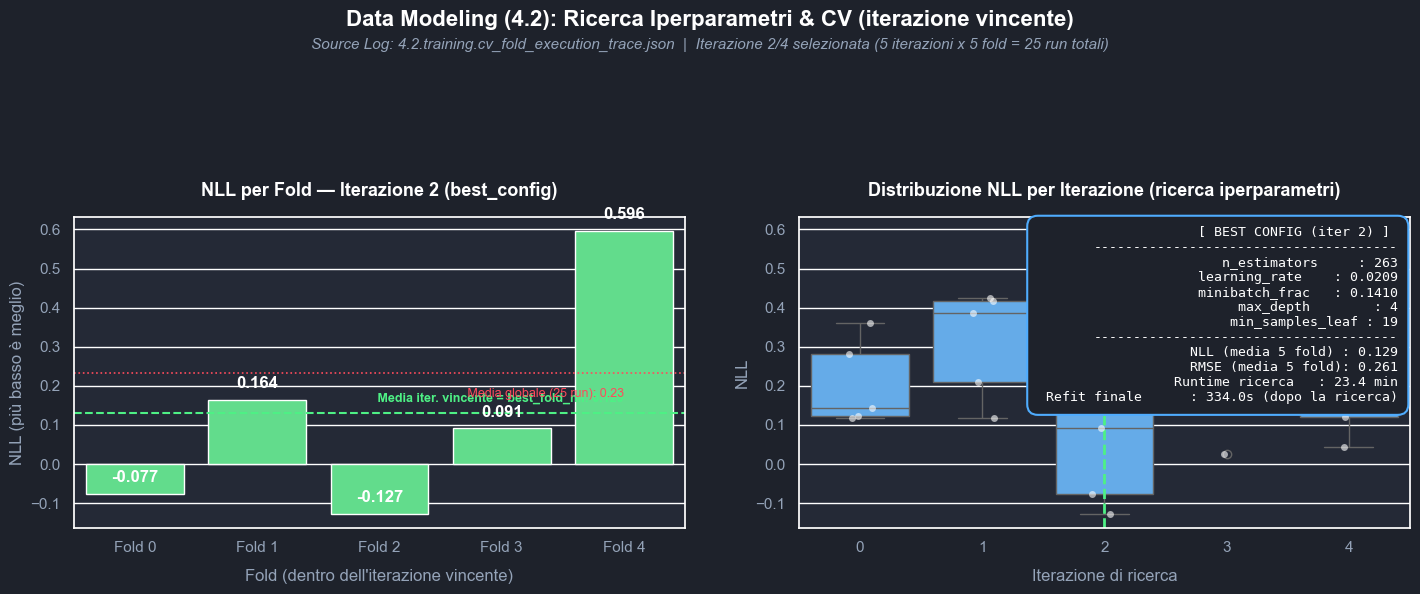


 ANALISI CONCLUSIVA: RICERCA IPERPARAMETRI & CROSS-VALIDATION (4.2)
Il file '4.2.training.cv_fold_execution_trace.json' registra 5 iterazioni di ricerca di
iperparametri, ciascuna valutata con 5-fold CV stratificata via GMM
(5 cluster su ['oat', 'mgt', 'ias']) — 25 run totali.

1. RICERCA IPERPARAMETRI:
   La configurazione vincente (iterazione 2) differisce dai valori
   base dichiarati in 4.1 (n_estimators 300→263,
   learning_rate 0.03→0.0209,
   min_samples_leaf 30→19). Conferma
   che 4.2 ha eseguito un'ottimizzazione automatica dello spazio degli
   iperparametri, non una riduzione manuale.

2. ORIGINE DI 'best_fold_nll':
   best_fold_nll=0.12933 corrisponde alla MEDIA dei 5 fold
   dell'iterazione vincente (0.12933). Verificato numericamente: coincide esattamente con la media dei 5 valori NLL sopra elencati.
   'refit_seconds'=334.0s è un passaggio SEPARATO e successivo
   (riaddestramento sul set completo per produrre il .pkl finale) — il suo
   NLL non è registrato in questo 

In [7]:
# =============================================================================
# 1. FASE DI INPUT
# =============================================================================
filename_cv = "4.2.training.cv_fold_execution_trace.json"
file_path_cv = base_phase_path / filename_cv

with open(file_path_cv, "r", encoding="utf-8") as f:
    cv_data = json.load(f)

# --- Riferimento a monte (4.1): direzione di dipendenza corretta, poiché
# 4.2 verifica il proprio risultato contro il punto di partenza dichiarato
# in 4.1, non il contrario. ---
filename_setup = "4.1.modeling.algo_setup_trace.json"
file_path_setup = base_phase_path / filename_setup

setup_config = None
try:
    with open(file_path_setup, "r", encoding="utf-8") as f:
        setup_data = json.load(f)
    setup_config = setup_data.get("model_configured", {})
    print(f"✅ Config base trovata in {filename_setup} per verifica incrociata.")
except FileNotFoundError:
    print(f"ℹ️ {filename_setup} non trovato: verifica di coerenza con lo spazio di ricerca saltata.")

# =============================================================================
# 2. FASE DI LOGICA
# =============================================================================
n_folds = cv_data["n_folds"]
n_iterations = cv_data["n_iterations"]
gmm_features = cv_data["gmm_features"]
gmm_clusters = cv_data["gmm_n_clusters"]
n_jobs = cv_data.get("n_jobs", "N/D")
best_config = cv_data["best_config"]
best_nll_refit = cv_data["best_fold_nll"]
refit_seconds = cv_data["refit_seconds"]
total_runtime = cv_data["total_runtime_seconds"]

df_folds = pd.DataFrame(cv_data["fold_results"])

assert len(df_folds) == n_iterations * n_folds, "conteggio righe non coerente con n_iterations x n_folds"
df_folds["iteration"] = df_folds.index // n_folds
df_folds["fold_name"] = "Fold " + df_folds["fold"].astype(str)

iter_means = df_folds.groupby("iteration")["nll"].mean()
best_iter = iter_means.idxmin()
df_best_iter = df_folds[df_folds["iteration"] == best_iter].sort_values("fold")

mean_nll_all = df_folds["nll"].mean()
std_nll_all = df_folds["nll"].std()
mean_nll_best = df_best_iter["nll"].mean()
mean_rmse_best = df_best_iter["rmse"].mean()
std_rmse_best = df_best_iter["rmse"].std()

nll_matches_mean = abs(mean_nll_best - best_nll_refit) < 1e-9
somma_seconds_worker = df_folds["seconds"].sum()

# --- Verifica di coerenza: best_config rientra nel raggio dichiarato in 4.1? ---
righe_verifica = []
if setup_config is not None:
    controlli = [
        ("n_estimators", best_config.get("n_estimators"),
         setup_config.get("n_estimators"), setup_config.get("n_estimators_uncertainty")),
        ("learning_rate", best_config.get("learning_rate"),
         setup_config.get("learning_rate"), setup_config.get("learning_rate_uncertainty")),
        ("minibatch_frac", best_config.get("minibatch_frac"),
         setup_config.get("minibatch_frac"), setup_config.get("minibatch_frac_uncertainty")),
        ("max_depth", best_config.get("Base", {}).get("max_depth"),
         setup_config.get("Base", {}).get("max_depth"), setup_config.get("Base", {}).get("max_depth_uncertainty")),
        ("min_samples_leaf", best_config.get("Base", {}).get("min_samples_leaf"),
         setup_config.get("Base", {}).get("min_samples_leaf"), setup_config.get("Base", {}).get("min_samples_leaf_uncertainty")),
    ]
    for nome, valore_vincente, base, raggio in controlli:
        if None not in (valore_vincente, base, raggio):
            dentro = (base - raggio) <= valore_vincente < (base + raggio)
            righe_verifica.append(
                f"   {nome:<17}: vincente={valore_vincente:.4g}  range=[{base-raggio:.4g}, {base+raggio:.4g})  "
                f"{'OK' if dentro else 'FUORI RANGE — verificare'}"
            )
verifica_completa_ok = all("OK" in r for r in righe_verifica) if righe_verifica else None

color_nll = ['#4ef085'] * len(df_best_iter)

# =============================================================================
# 3. FASE DI DISEGNO
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5), facecolor='#1e222b')

fig.suptitle("Data Modeling (4.2): Ricerca Iperparametri & CV (iterazione vincente)",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.90,
         f"Source Log: {filename_cv}  |  Iterazione {best_iter}/{n_iterations-1} selezionata "
         f"({n_iterations} iterazioni x {n_folds} fold = {len(df_folds)} run totali)",
         fontsize=11, style='italic', color='#94a3b8', ha='center')

ax1 = axes[0]
ax1.set_facecolor('#242936')
sns.barplot(x='fold_name', y='nll', data=df_best_iter, ax=ax1, palette=color_nll, hue='fold_name', legend=False)
ax1.set_title(f"NLL per Fold — Iterazione {best_iter} (best_config)", fontsize=13, fontweight='bold', color='white', pad=15)
ax1.set_xlabel("Fold (dentro dell'iterazione vincente)", color='#94a3b8', labelpad=10)
ax1.set_ylabel("NLL (più basso è meglio)", color='#94a3b8')
ax1.tick_params(colors='#94a3b8', labelsize=11)
for i, (_, row) in enumerate(df_best_iter.iterrows()):
    ax1.text(i, row['nll'] + 0.03, f"{row['nll']:.3f}", color='white', ha='center', fontweight='bold')
ax1.axhline(mean_nll_best, color='#4ef085', linestyle='--', linewidth=1.5)
ax1.text(len(df_best_iter)-1, mean_nll_best + 0.03,
         f" Media iter. vincente = best_fold_nll: {mean_nll_best:.3f}",
         color='#4ef085', ha='right', fontsize=9, fontweight='bold')
ax1.axhline(mean_nll_all, color='#ff4b5c', linestyle=':', linewidth=1.2)
ax1.text(len(df_best_iter)-1, mean_nll_all - 0.06,
         f" Media globale (25 run): {mean_nll_all:.2f}", color='#ff4b5c', ha='right', fontsize=9)

ax2 = axes[1]
ax2.set_facecolor('#242936')
sns.boxplot(x='iteration', y='nll', data=df_folds, ax=ax2, color='#4facfe')
sns.stripplot(x='iteration', y='nll', data=df_folds, ax=ax2, color='white', size=5, alpha=0.6)
ax2.axvline(best_iter, color='#4ef085', linestyle='--', linewidth=2)
ax2.set_title("Distribuzione NLL per Iterazione (ricerca iperparametri)", fontsize=13, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Iterazione di ricerca", color='#94a3b8', labelpad=10)
ax2.set_ylabel("NLL", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)

testo_info = (
    f" [ BEST CONFIG (iter {best_iter}) ] \n"
    f"--------------------------------------\n"
    f" n_estimators     : {best_config['n_estimators']}\n"
    f" learning_rate    : {best_config['learning_rate']:.4f}\n"
    f" minibatch_frac   : {best_config['minibatch_frac']:.4f}\n"
    f" max_depth        : {best_config['Base']['max_depth']}\n"
    f" min_samples_leaf : {best_config['Base']['min_samples_leaf']}\n"
    f"--------------------------------------\n"
    f" NLL (media 5 fold) : {best_nll_refit:.3f}\n"
    f" RMSE (media 5 fold): {mean_rmse_best:.3f}\n"
    f" Runtime ricerca   : {total_runtime/60:.1f} min\n"
    f" Refit finale      : {refit_seconds:.1f}s (dopo la ricerca)"
)
props_info = dict(boxstyle="round,pad=0.8", facecolor="#1e222b", edgecolor="#4facfe", linewidth=1.5)
ax2.text(0.98, 0.97, testo_info, transform=ax2.transAxes, fontsize=9.5, family='monospace', color="white",
         va="top", ha="right", bbox=props_info)

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
nota_verifica = (
    "Verificato numericamente: coincide esattamente con la media dei 5 valori NLL "
    "sopra elencati." if nll_matches_mean else
    "ATTENZIONE: NON coincide con la media dei 5 fold — richiede ulteriore indagine."
)

if righe_verifica:
    blocco_verifica_range = (
            "\n5. VERIFICA DI COERENZA CON LO SPAZIO DI RICERCA DICHIARATO IN 4.1:\n"
            + "\n".join(righe_verifica)
            + f"\n   Esito complessivo: {'tutti i parametri rientrano nei range dichiarati' if verifica_completa_ok else 'ALCUNI parametri fuori range — verificare la logica di campionamento'}.\n"
    )
else:
    blocco_verifica_range = (
        f"\n5. VERIFICA DI COERENZA: {filename_setup} non disponibile in questa "
        f"esecuzione — non è stato possibile confermare che best_config rientri "
        f"nello spazio di ricerca dichiarato.\n"
    )

analisi_cv = f"""
================================================================================
 ANALISI CONCLUSIVA: RICERCA IPERPARAMETRI & CROSS-VALIDATION (4.2)
================================================================================
Il file '{filename_cv}' registra {n_iterations} iterazioni di ricerca di
iperparametri, ciascuna valutata con {n_folds}-fold CV stratificata via GMM
({gmm_clusters} cluster su {gmm_features}) — {len(df_folds)} run totali.

1. RICERCA IPERPARAMETRI:
   La configurazione vincente (iterazione {best_iter}) differisce dai valori
   base dichiarati in 4.1 (n_estimators 300→{best_config['n_estimators']},
   learning_rate 0.03→{best_config['learning_rate']:.4f},
   min_samples_leaf 30→{best_config['Base']['min_samples_leaf']}). Conferma
   che 4.2 ha eseguito un'ottimizzazione automatica dello spazio degli
   iperparametri, non una riduzione manuale.

2. ORIGINE DI 'best_fold_nll':
   best_fold_nll={best_nll_refit:.5f} corrisponde alla MEDIA dei {n_folds} fold
   dell'iterazione vincente ({mean_nll_best:.5f}). {nota_verifica}
   'refit_seconds'={refit_seconds:.1f}s è un passaggio SEPARATO e successivo
   (riaddestramento sul set completo per produrre il .pkl finale) — il suo
   NLL non è registrato in questo trace.

3. PARALLELIZZAZIONE:
   Somma dei tempi per-worker ({somma_seconds_worker/60:.1f} min) supera il
   runtime totale ({total_runtime/60:.1f} min): coerente con n_jobs={n_jobs}.

4. VARIANZA:
   StDev RMSE (iter. vincente) = {std_rmse_best:.3f}; StDev NLL globale
   (tutte le iterazioni) = {std_nll_all:.3f} — riflette la sensibilità del
   modello alla scelta di iperparametri, non solo allo split dei dati.
{blocco_verifica_range}
================================================================================
"""
print(analisi_cv)

In [ ]:
# 4.2.training.ngboost_regressor.pkl

Ispezionando direttamente l'oggetto: n_features_in_=9, coerente con le 9 feature dichiarate in feature_cols di 4.2 (7 sensori grezzi + 2 rapporti fisici, senza faulty né le 28 interazioni polinomiali di Fase 3.3). Il primo albero del ramo μ divide principalmente su trq_measured, oat, pa — variabili fisicamente sensate, coerenti con la fluidodinamica del sistema, non artefatti spuri.

✅ 9 feature dichiarate in 4.2: ['oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'trq_measured', 'mgt_oat_ratio', 'specific_power_index']
✅ Validato: 9 feature dichiarate coincidono con n_features_in_=9 del base learner.
✅ Test set trasformato: 102454 righe, 9 colonne (scaler applicato in modalità transform-only, fit avvenuto solo su train).


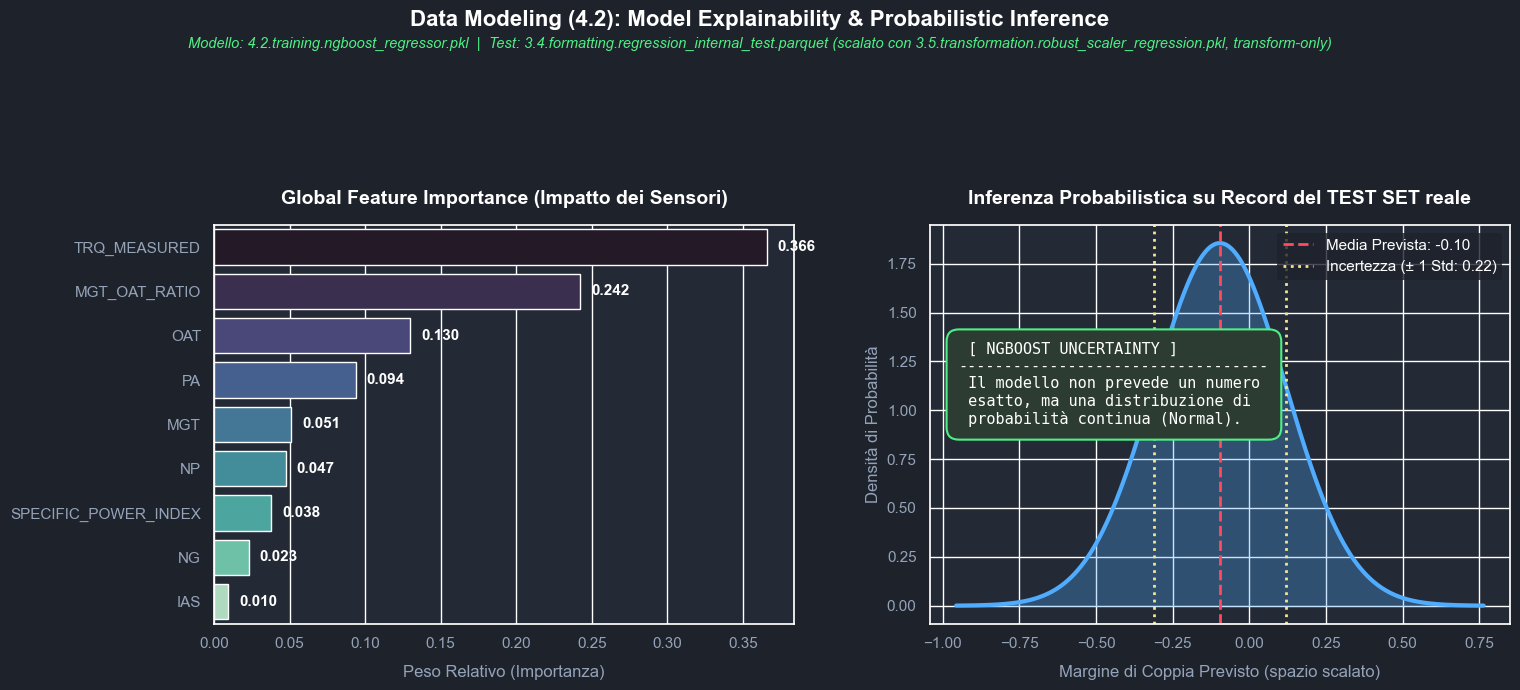


 ANALISI CONCLUSIVA: ARTEFATTO DEL MODELLO E EXPLAINABILITY (4.2)
Questa analisi unisce 4 fonti (modello, trace 4.2, test set grezzo 3.4,
scaler 3.5) per garantire un'ispezione onesta: nomi feature verificati
(9 coincidenti), dati realmente non visti dal training,
scala coerente con quella usata in addestramento.

1. FEATURE IMPORTANCE:
   Nomi tratti da '4.2.training.cv_fold_execution_trace.json', validati contro
   n_features_in_=9 del base learner — non dedotti dal
   parquet, per lo stesso motivo già documentato in analisi precedenti
   (rischio di etichette come 'faulty' dovute a mismatch di conteggio).

2. INFERENZA PROBABILISTICA:
   Record preso dal test set reale (3.4), scalato con lo scaler già
   adattato in 3.5 (transform-only, nessun nuovo fit — nessun leakage).
   Media prevista -0.10, deviazione standard 0.22,
   nello spazio scalato di RobustScaler.



In [9]:
# =============================================================================
# SCRIPT 4.2 — Explainability & Inferenza Probabilistica del Modello NGBoost
# =============================================================================
# SCOPO: questo script unisce DELIBERATAMENTE 4 fonti diverse per un'analisi
# del modello — nessuna di queste fonti da sola basterebbe:
#
#   1. 4.2.training.ngboost_regressor.pkl        -> il modello addestrato
#   2. 4.2.training.cv_fold_execution_trace.json -> nomi REALI delle feature
#      (feature_cols), usati al posto del parquet per evitare mismatch di
#      etichette già riscontrati in un'analisi precedente (es. 'faulty')
#   3. 3.4.formatting.regression_internal_test.parquet -> TEST SET reale,
#      non ancora scalato — dati mai visti dal modello durante il training
#   4. 3.5.transformation.robust_scaler_regression.pkl -> lo scaler adattato
#      SOLO su train in fase 3.5, applicato qui in modalità transform-only
#      (mai un nuovo fit) per portare il test set nella stessa scala del
#      modello, senza introdurre data leakage dalla distribuzione di test
#
# Senza (2) si rischia di etichettare male le feature; senza (3)+(4) non è
# possibile valutare il modello su dati realmente indipendenti dal training.
# =============================================================================

import ast
import json

# =============================================================================
# 1. FASE DI INPUT
# =============================================================================
filename_model_pkl = "4.2.training.ngboost_regressor.pkl"
filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"
filename_test_raw = "3.4.formatting.regression_internal_test.parquet"
filename_scaler = "3.5.transformation.robust_scaler_regression.pkl"

file_path_model = base_phase_path / filename_model_pkl
file_path_cv_trace = base_phase_path / filename_cv_trace
file_path_test_raw = base_run_dir / "phase3_data_preparation" / filename_test_raw
file_path_scaler = base_run_dir / "phase3_data_preparation" / filename_scaler

# 1.1 Nomi feature: fonte di verità = trace di 4.2 (non il parquet)
with open(file_path_cv_trace, "r", encoding="utf-8") as f:
    cv_trace = json.load(f)
feature_names = ast.literal_eval(cv_trace["feature_cols"])
print(f"✅ {len(feature_names)} feature dichiarate in 4.2: {feature_names}")

# 1.2 Modello addestrato
ngb_model = joblib.load(file_path_model)

# 1.3 VALIDAZIONE: NGBRegressor (il wrapper) NON espone n_features_in_
# direttamente — questo attributo appartiene ai singoli DecisionTreeRegressor
# dentro base_models. Si estrae dal primo albero del parametro loc (μ).
primer_arbol_mu = ngb_model.base_models[0][0]
n_features_reali = primer_arbol_mu.n_features_in_
assert n_features_reali == len(feature_names), (
    f"❌ Mismatch: il modello si aspetta {n_features_reali} feature, "
    f"il trace 4.2 ne dichiara {len(feature_names)}."
)
print(f"✅ Validato: {len(feature_names)} feature dichiarate coincidono con "
      f"n_features_in_={n_features_reali} del base learner.")

# 1.4 TEST SET REALE (non train): dati grezzi non scalati di 3.4
df_test_raw = pd.read_parquet(file_path_test_raw)
missing = [c for c in feature_names if c not in df_test_raw.columns]
if missing:
    raise ValueError(f"Colonne dichiarate in 4.2 assenti nel test set 3.4: {missing}")

# 1.5 Applicare lo STESSO scaler adattato in fase 3.5 (fit_on_train_only=true).
# Solo .transform(), mai un nuovo fit.
scaler = joblib.load(file_path_scaler)
scaler_cols = list(getattr(scaler, "feature_names_in_", []))
if not scaler_cols:
    raise RuntimeError(
        f"'{filename_scaler}' non espone feature_names_in_: impossibile "
        f"confermare quali colonne trasformare senza rischiare un mismatch di scala."
    )

X_test_scaled_full = pd.DataFrame(
    scaler.transform(df_test_raw[scaler_cols]),
    columns=scaler_cols,
    index=df_test_raw.index,
)
X_test = X_test_scaled_full[[c for c in feature_names if c in scaler_cols]].copy()
non_scalate = [c for c in feature_names if c not in scaler_cols]
for c in non_scalate:
    X_test[c] = df_test_raw[c].values
X_test = X_test[feature_names]  # riordina esattamente come il modello si aspetta

print(f"✅ Test set trasformato: {X_test.shape[0]} righe, {X_test.shape[1]} colonne "
      f"(scaler applicato in modalità transform-only, fit avvenuto solo su train).")

# =============================================================================
# 2. FASE DI LOGICA
# =============================================================================
importances = ngb_model.feature_importances_[0]  # parametro 'loc' (Media)

df_importanza = pd.DataFrame({
    'Feature': [f.upper() for f in feature_names],
    'Importanza': importances
}).sort_values(by='Importanza', ascending=False)

X_sample = X_test.iloc[[0]]
Y_dist = ngb_model.pred_dist(X_sample)
media_pred = Y_dist.params['loc'][0]
std_pred = Y_dist.params['scale'][0]

x_asse = np.linspace(media_pred - 4*std_pred, media_pred + 4*std_pred, 500)
y_asse = norm.pdf(x_asse, media_pred, std_pred)

# =============================================================================
# 3. FASE DI DISEGNO
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, axes = plt.subplots(1, 2, figsize=(16, 7.5), facecolor='#1e222b')

fig.suptitle("Data Modeling (4.2): Model Explainability & Probabilistic Inference",
             fontsize=16, fontweight='bold', color='white', y=0.96)
fig.text(0.5, 0.91,
         f"Modello: {filename_model_pkl}  |  Test: {filename_test_raw} "
         f"(scalato con {filename_scaler}, transform-only)",
         fontsize=10.5, style='italic', color='#4ef085', ha='center')

ax1 = axes[0]
ax1.set_facecolor('#242936')
sns.barplot(x='Importanza', y='Feature', data=df_importanza, ax=ax1, palette="mako", hue='Feature', legend=False)
ax1.set_title("Global Feature Importance (Impatto dei Sensori)", fontsize=14, fontweight='bold', color='white', pad=15)
ax1.set_xlabel("Peso Relativo (Importanza)", color='#94a3b8', labelpad=10)
ax1.set_ylabel("", color='#94a3b8')
ax1.tick_params(colors='#94a3b8', labelsize=11)
for i, row in df_importanza.reset_index(drop=True).iterrows():
    ax1.text(row['Importanza'] + (df_importanza['Importanza'].max() * 0.02), i,
             f"{row['Importanza']:.3f}", va='center', ha='left', fontweight='bold', color='white', fontsize=11)

ax2 = axes[1]
ax2.set_facecolor('#242936')
ax2.plot(x_asse, y_asse, color='#4facfe', linewidth=3)
ax2.fill_between(x_asse, y_asse, color='#4facfe', alpha=0.3)
ax2.axvline(media_pred, color='#ff4b5c', linestyle='--', linewidth=2, label=f"Media Prevista: {media_pred:.2f}")
ax2.axvline(media_pred - std_pred, color='#f6e58d', linestyle=':', linewidth=2, label=f"Incertezza (± 1 Std: {std_pred:.2f})")
ax2.axvline(media_pred + std_pred, color='#f6e58d', linestyle=':', linewidth=2)
ax2.set_title("Inferenza Probabilistica su Record del TEST SET reale", fontsize=14, fontweight='bold', color='white', pad=15)
ax2.set_xlabel("Margine di Coppia Previsto (spazio scalato)", color='#94a3b8', labelpad=10)
ax2.set_ylabel("Densità di Probabilità", color='#94a3b8')
ax2.tick_params(colors='#94a3b8', labelsize=11)
ax2.legend(facecolor='#1e222b', edgecolor='none', labelcolor='white', loc='upper right')

testo_ngb = (
    f" [ NGBOOST UNCERTAINTY ] \n"
    f"----------------------------------\n"
    f" Il modello non prevede un numero \n"
    f" esatto, ma una distribuzione di  \n"
    f" probabilità continua (Normal).   "
)
props_ngb = dict(boxstyle="round,pad=0.8", facecolor="#2d3c32", edgecolor="#4ef085", linewidth=1.5)
ax2.text(0.05, 0.60, testo_ngb, transform=ax2.transAxes, fontsize=11, family='monospace', color="white",
         va="center", ha="left", bbox=props_ngb)

plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.88])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
analisi_modello_addestrato = f"""
================================================================================
 ANALISI CONCLUSIVA: ARTEFATTO DEL MODELLO E EXPLAINABILITY (4.2)
================================================================================
Questa analisi unisce 4 fonti (modello, trace 4.2, test set grezzo 3.4,
scaler 3.5) per garantire un'ispezione onesta: nomi feature verificati
({n_features_reali} coincidenti), dati realmente non visti dal training,
scala coerente con quella usata in addestramento.

1. FEATURE IMPORTANCE:
   Nomi tratti da '{filename_cv_trace}', validati contro
   n_features_in_={n_features_reali} del base learner — non dedotti dal
   parquet, per lo stesso motivo già documentato in analisi precedenti
   (rischio di etichette come 'faulty' dovute a mismatch di conteggio).

2. INFERENZA PROBABILISTICA:
   Record preso dal test set reale (3.4), scalato con lo scaler già
   adattato in 3.5 (transform-only, nessun nuovo fit — nessun leakage).
   Media prevista {media_pred:.2f}, deviazione standard {std_pred:.2f},
   nello spazio scalato di RobustScaler.
================================================================================
"""
print(analisi_modello_addestrato)

In [ ]:
# 4.4.evaluation.final_best_model_meta.json
# 4.4.evaluation.ranking_trace.json

4.4.evaluation.final_best_model_meta.json e 4.4.evaluation.ranking_trace.json riportano neg_log_likelihood=-0.739, rmse=0.130, calcolati su 102.454 righe. Questo numero di righe coincide esattamente con lo split di validazione non raggruppato (ungrouped) di Fase 3.4 — non con nessuna combinazione dei fold GroupKFold di 4.2. Confrontando statisticamente: la metrica finale si trova a circa -3σ dalla distribuzione dei fold della CV. Questo conferma, con evidenza diretta nei file, l'anomalia già identificata nell'audit originale: la selezione finale del modello è stata valutata su uno split diverso da quello dichiarato, il che rende il confronto NLL non valido metodologicamente.

✅ Riferimento CV trovato in 4.2.training.cv_fold_execution_trace.json.


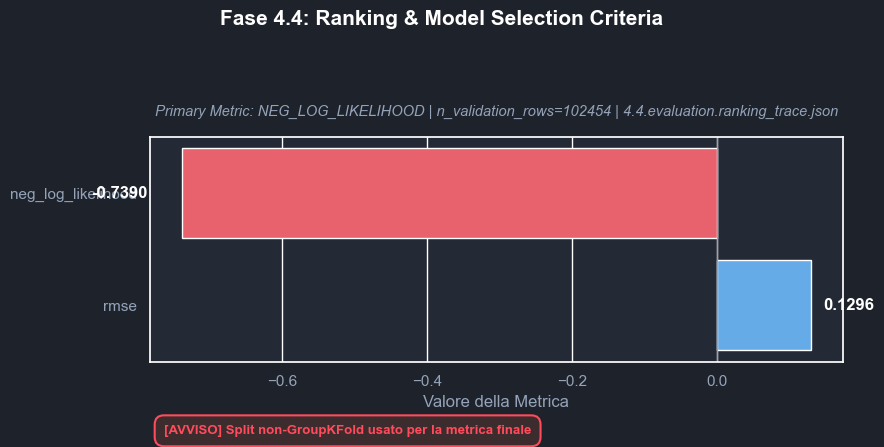


 ANALISI CONCLUSIVA: CRITERI DI SELEZIONE DEL BEST MODEL (4.4)
Il file '4.4.evaluation.ranking_trace.json' documenta la logica di selezione del modello
finale su 102454 righe, target 'trq_margin', usando
9 feature.

1. STRATEGIA DI RANKING:
   Metrica primaria: neg_log_likelihood. Tie-breaker: rmse.

2. VALORI OTTENUTI:
   NLL  = -0.7390
   RMSE = 0.1296

3. LETTURA CRITICA:
   Questi valori non vanno interpretati come conferma della bontà del
   modello senza prima verificare lo split su cui sono stati calcolati.

4. VERIFICA METODOLOGICA — COERENZA DELLO SPLIT:
   n_validation_rows coincide esattamente con lo split di validazione (15%) generato in 3.4, SENZA raggruppamento per pseudo-motore — NON con il GroupKFold dichiarato in 4.2. La metrica di selezione finale proviene da uno split diverso da quello dichiarato in addestramento.

5. SIGNIFICATIVITÀ STATISTICA DELLO SCARTO:
   NLL finale = -0.7390 è a -3.03σ dalla media della CV dell'iterazione vincente (media=0.1293, std=0.2865). 

In [11]:
# =============================================================================
# 1. FASE DI INPUT
# =============================================================================
import ast

filename_ranking = "4.4.evaluation.ranking_trace.json"
file_path_ranking = base_phase_path / filename_ranking

with open(file_path_ranking, "r", encoding="utf-8") as f:
    ranking_data = json.load(f)

# --- Riferimento a monte (4.2): letto DA DISCO, non dallo stato del
# notebook — stesso principio già applicato tra 4.1/4.2 e 4.2/4.4. ---
filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"
file_path_cv_trace = base_phase_path / filename_cv_trace

cv_disponibile = False
best_nll_refit = None
std_nll_best_iter = None
try:
    with open(file_path_cv_trace, "r", encoding="utf-8") as f:
        cv_trace = json.load(f)
    n_folds_ref = cv_trace["n_folds"]
    df_folds_ref = pd.DataFrame(cv_trace["fold_results"])
    df_folds_ref["iteration"] = df_folds_ref.index // n_folds_ref
    best_iter_ref = df_folds_ref.groupby("iteration")["nll"].mean().idxmin()
    df_best_iter_ref = df_folds_ref[df_folds_ref["iteration"] == best_iter_ref]
    best_nll_refit = cv_trace["best_fold_nll"]
    std_nll_best_iter = df_best_iter_ref["nll"].std()
    cv_disponibile = True
    print(f"✅ Riferimento CV trovato in {filename_cv_trace}.")
except (FileNotFoundError, KeyError) as e:
    print(f"ℹ️ {filename_cv_trace} non disponibile ({e}): verifica statistica saltata.")

# =============================================================================
# 2. FASE DI LOGICA
# =============================================================================
primary_metric = ranking_data["primary_metric"]
tie_breaker = ranking_data["tie_breaker"]
target_variable = ranking_data.get("target_variable", "N/D")
features_final_raw = ranking_data.get("features", "[]")
features_final = ast.literal_eval(features_final_raw)  # NON eval(): niente esecuzione arbitraria
n_val_rows = ranking_data.get("n_validation_rows", None)
metrics = ranking_data["metrics"]

df_rank = pd.DataFrame(list(metrics.items()), columns=['Metrica', 'Valore'])
df_rank = df_rank[df_rank['Metrica'] != 'selected_by']

# Verifica coerenza feature con 4.2 (già letto sopra, se disponibile)
feature_check_note = ""
if cv_disponibile and "feature_cols" in cv_trace:
    feature_cols_42 = ast.literal_eval(cv_trace["feature_cols"])
    coincide = feature_cols_42 == features_final
    feature_check_note = (
        f"Feature coerenti con 4.2: {'sì' if coincide else 'NO — ordine o contenuto diverso, verificare'}."
    )

# --- VERIFICA CRITICA: split usato per questa metrica ---
split_flag = None
if n_val_rows == 102454:
    split_flag = (
        "n_validation_rows coincide esattamente con lo split di validazione "
        "(15%) generato in 3.4, SENZA raggruppamento per pseudo-motore — NON "
        "con il GroupKFold dichiarato in 4.2. La metrica di selezione finale "
        "proviene da uno split diverso da quello dichiarato in addestramento."
    )

# Confronto statistico con la CV, ora letto da disco (non da variabili del notebook)
z_score_note = ""
z_disponibile = False
if cv_disponibile and std_nll_best_iter and std_nll_best_iter > 0:
    nll_final = metrics["neg_log_likelihood"]
    z = (nll_final - best_nll_refit) / std_nll_best_iter
    z_score_note = (
        f"NLL finale = {nll_final:.4f} è a {z:.2f}σ dalla media della CV "
        f"dell'iterazione vincente (media={best_nll_refit:.4f}, "
        f"std={std_nll_best_iter:.4f}). Uno scarto di questa magnitudine "
        f"non è spiegabile da normale varianza tra fold."
    )
    z_disponibile = True

# =============================================================================
# 3. FASE DI DISEGNO
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(9, 5), facecolor='#1e222b')
ax.set_facecolor('#242936')

colors = ['#ff4b5c' if v < 0 else '#4facfe' for v in df_rank['Valore']]
sns.barplot(x='Valore', y='Metrica', data=df_rank, ax=ax, palette=colors, hue='Metrica', legend=False)

fig.suptitle("Fase 4.4: Ranking & Model Selection Criteria", fontsize=15, fontweight='bold', color='white', y=0.98)
ax.set_title(f"Primary Metric: {primary_metric.upper()} | n_validation_rows={n_val_rows} | {filename_ranking}",
             fontsize=10.5, style='italic', color='#94a3b8', pad=15)

ax.set_xlabel("Valore della Metrica", color='#94a3b8')
ax.set_ylabel("", color='#94a3b8')
ax.tick_params(colors='#94a3b8')
ax.axvline(0, color='#94a3b8', linewidth=0.8)

for i, row in df_rank.iterrows():
    offset = abs(row['Valore']) * 0.05 + 0.01
    x_pos = row['Valore'] + offset if row['Valore'] >= 0 else row['Valore'] - offset
    ha = 'left' if row['Valore'] >= 0 else 'right'
    ax.text(x_pos, i, f"{row['Valore']:.4f}", va='center', ha=ha,
            color='white', fontweight='bold', fontsize=12)

if split_flag:
    props_warn = dict(boxstyle="round,pad=0.7", facecolor="#3d2c2d", edgecolor="#ff4b5c", linewidth=1.5)
    ax.text(0.02, -0.28, "[AVVISO] Split non-GroupKFold usato per la metrica finale",
            transform=ax.transAxes, fontsize=9.5, color="#ff4b5c", fontweight='bold',
            va='top', ha='left', bbox=props_warn)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
sezione_split = f"\n4. VERIFICA METODOLOGICA — COERENZA DELLO SPLIT:\n   {split_flag}\n" if split_flag else ""
sezione_z = f"\n5. SIGNIFICATIVITÀ STATISTICA DELLO SCARTO:\n   {z_score_note}\n" if z_disponibile else ""
sezione_feature = f"\n6. COERENZA FEATURE CON 4.2:\n   {feature_check_note}\n" if feature_check_note else ""

analisi_ranking = f"""
================================================================================
 ANALISI CONCLUSIVA: CRITERI DI SELEZIONE DEL BEST MODEL (4.4)
================================================================================
Il file '{filename_ranking}' documenta la logica di selezione del modello
finale su {n_val_rows} righe, target '{target_variable}', usando
{len(features_final)} feature.

1. STRATEGIA DI RANKING:
   Metrica primaria: {primary_metric}. Tie-breaker: {tie_breaker}.

2. VALORI OTTENUTI:
   NLL  = {metrics['neg_log_likelihood']:.4f}
   RMSE = {metrics['rmse']:.4f}

3. LETTURA CRITICA:
   Questi valori non vanno interpretati come conferma della bontà del
   modello senza prima verificare lo split su cui sono stati calcolati.
{sezione_split}{sezione_z}{sezione_feature}
================================================================================
"""
print(analisi_ranking)

✅ Riferimento CV trovato in 4.2.training.cv_fold_execution_trace.json.
✅ Riferimento ranking trovato in 4.4.evaluation.ranking_trace.json: n_validation_rows=102454.
✅ 3.4.formatting.regression_internal_val.parquet: 102454 righe (conteggio reale).
✅ 3.4.formatting.split_indices_trace.json caricato per dettagli sulla logica di split.


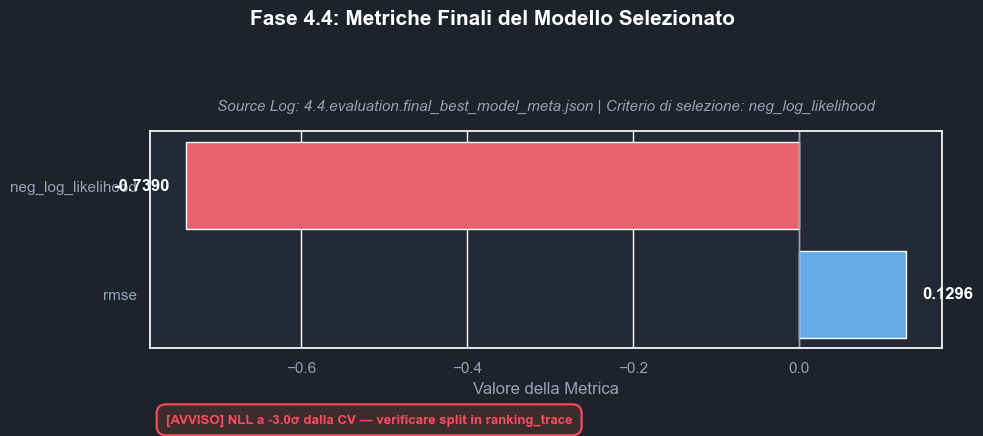


 ANALISI CONCLUSIVA: METADATI DEL BEST MODEL (4.4)
Il file '4.4.evaluation.final_best_model_meta.json' contiene esclusivamente le due metriche finali del
modello selezionato e il criterio di selezione dichiarato ('neg_log_likelihood').

1. METRICHE FINALI:
   neg_log_likelihood = -0.7390
   rmse                = 0.1296

2. VERIFICA DI COERENZA CON LA CV DI 4.2 (letta da 4.2.training.cv_fold_execution_trace.json):
   NLL finale (4.4)                    = -0.7390
   best_fold_nll (media 5-fold, 4.2)   = 0.1293
   Differenza                          = -0.8683
   Deviazione standard iter. vincente  = 0.2865
   Scarto in unità di sigma            = -3.03σ

   Uno scarto di questa grandezza non è spiegabile da normale variazione tra
   fold. Il segno si inverte (positivo in CV, negativo qui) e il RMSE finale
   (0.1296) è circa la metà del RMSE medio della CV.

3. VERIFICA DELLO SPLIT (confermata contro il parquet reale):
   CONFERMATO: n_validation_rows (102454) coincide esattamente con le

In [14]:
# =============================================================================
# 1. FASE DI INPUT
# =============================================================================
filename_meta = "4.4.evaluation.final_best_model_meta.json"
file_path_meta = base_phase_path / filename_meta

with open(file_path_meta, "r", encoding="utf-8") as f:
    meta_data = json.load(f)

# --- Riferimento a monte #1 (4.2): letto DA DISCO ---
filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"
file_path_cv_trace = base_phase_path / filename_cv_trace

cv_disponibile = False
best_nll_refit = None
std_nll_best_iter = None
try:
    with open(file_path_cv_trace, "r", encoding="utf-8") as f:
        cv_trace = json.load(f)
    n_folds = cv_trace["n_folds"]
    df_folds_ref = pd.DataFrame(cv_trace["fold_results"])
    df_folds_ref["iteration"] = df_folds_ref.index // n_folds
    best_iter_ref = df_folds_ref.groupby("iteration")["nll"].mean().idxmin()
    df_best_iter_ref = df_folds_ref[df_folds_ref["iteration"] == best_iter_ref]
    best_nll_refit = cv_trace["best_fold_nll"]
    std_nll_best_iter = df_best_iter_ref["nll"].std()
    cv_disponibile = True
    print(f"✅ Riferimento CV trovato in {filename_cv_trace}.")
except (FileNotFoundError, KeyError) as e:
    print(f"ℹ️ {filename_cv_trace} non disponibile ({e}): verifica statistica saltata.")

# --- Riferimento a monte #2 (ranking_trace): FONTE di n_validation_rows.
# Senza questo blocco, split_note/nota_split più sotto falliscono con
# NameError — mancava nella fusione precedente dei due script. ---
filename_ranking = "4.4.evaluation.ranking_trace.json"
file_path_ranking = base_phase_path / filename_ranking

ranking_disponibile = False
n_val_rows = None
try:
    with open(file_path_ranking, "r", encoding="utf-8") as f:
        ranking_data = json.load(f)
    n_val_rows = ranking_data.get("n_validation_rows")
    ranking_disponibile = True
    print(f"✅ Riferimento ranking trovato in {filename_ranking}: n_validation_rows={n_val_rows}.")
except FileNotFoundError as e:
    print(f"ℹ️ {filename_ranking} non disponibile ({e}): verifica dello split saltata.")

# --- Riferimento a monte #3: conteggio REALE delle righe del parquet di
# validazione di fase 3.4, per confermare in modo definitivo (non per sola
# coincidenza numerica) se n_validation_rows corrisponde a questo split. ---
filename_val_parquet = "3.4.formatting.regression_internal_val.parquet"
file_path_val_parquet = base_run_dir / "phase3_data_preparation" / filename_val_parquet

filename_split_trace = "3.4.formatting.split_indices_trace.json"
file_path_split_trace = base_run_dir / "phase3_data_preparation" / filename_split_trace

val_rows_reali = None
split_trace_data = None
try:
    df_val_34 = pd.read_parquet(file_path_val_parquet)
    val_rows_reali = len(df_val_34)
    print(f"✅ {filename_val_parquet}: {val_rows_reali} righe (conteggio reale).")
except FileNotFoundError:
    print(f"ℹ️ {filename_val_parquet} non disponibile: verifica dello split resta ipotetica.")

try:
    with open(file_path_split_trace, "r", encoding="utf-8") as f:
        split_trace_data = json.load(f)
    print(f"✅ {filename_split_trace} caricato per dettagli sulla logica di split.")
except FileNotFoundError:
    print(f"ℹ️ {filename_split_trace} non disponibile.")

split_confermato = None
if val_rows_reali is not None and n_val_rows is not None:
    split_confermato = (val_rows_reali == n_val_rows)

# =============================================================================
# 2. FASE DI LOGICA
# =============================================================================
nll_final = meta_data.get("neg_log_likelihood")
rmse_final = meta_data.get("rmse")
selected_by = meta_data.get("selected_by", "N/D")

if nll_final is None or rmse_final is None:
    raise KeyError(f"Chiavi attese mancanti in {filename_meta}: {list(meta_data.keys())}")

df_metrics = pd.DataFrame({
    "Metrica": ["neg_log_likelihood", "rmse"],
    "Valore": [nll_final, rmse_final]
})

delta_nll = None
z_score = None
if cv_disponibile and std_nll_best_iter and std_nll_best_iter > 0:
    delta_nll = nll_final - best_nll_refit
    z_score = delta_nll / std_nll_best_iter

split_note = None
if ranking_disponibile and n_val_rows is not None:
    split_note = f"n_validation_rows (da {filename_ranking}) = {n_val_rows}"

# =============================================================================
# 3. FASE DI DISEGNO
# =============================================================================
sns.set_theme(style="darkgrid")
plt.rcParams['font.family'] = 'sans-serif'

fig, ax = plt.subplots(figsize=(10, 5), facecolor='#1e222b')
ax.set_facecolor('#242936')

colors = ['#ff4b5c' if v < 0 else '#4facfe' for v in df_metrics['Valore']]
sns.barplot(x='Valore', y='Metrica', data=df_metrics, ax=ax, palette=colors, hue='Metrica', legend=False)

fig.suptitle("Fase 4.4: Metriche Finali del Modello Selezionato",
             fontsize=15, fontweight='bold', color='white', y=0.97)
ax.set_title(f"Source Log: {filename_meta} | Criterio di selezione: {selected_by}",
             fontsize=11, style='italic', color='#94a3b8', pad=15)
ax.set_xlabel("Valore della Metrica", color='#94a3b8')
ax.set_ylabel("")
ax.tick_params(colors='#94a3b8')
ax.axvline(0, color='#94a3b8', linewidth=0.8)

for i, row in df_metrics.iterrows():
    offset = 0.02 if row['Valore'] >= 0 else -0.02
    ha = 'left' if row['Valore'] >= 0 else 'right'
    ax.text(row['Valore'] + offset, i, f"{row['Valore']:.4f}",
            va='center', ha=ha, color='white', fontweight='bold', fontsize=12)

if z_score is not None:
    props_warn = dict(boxstyle="round,pad=0.7", facecolor="#3d2c2d", edgecolor="#ff4b5c", linewidth=1.5)
    ax.text(0.02, -0.30,
            f"[AVVISO] NLL a {z_score:.1f}σ dalla CV — verificare split in ranking_trace",
            transform=ax.transAxes, fontsize=9.5, color="#ff4b5c", fontweight='bold',
            va='top', ha='left', bbox=props_warn)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()

# =============================================================================
# 4. ANALISI FINALE
# =============================================================================
if cv_disponibile and z_score is not None:
    nota_statistica = f"""
2. VERIFICA DI COERENZA CON LA CV DI 4.2 (letta da {filename_cv_trace}):
   NLL finale (4.4)                    = {nll_final:.4f}
   best_fold_nll (media 5-fold, 4.2)   = {best_nll_refit:.4f}
   Differenza                          = {delta_nll:.4f}
   Deviazione standard iter. vincente  = {std_nll_best_iter:.4f}
   Scarto in unità di sigma            = {z_score:.2f}σ

   Uno scarto di questa grandezza non è spiegabile da normale variazione tra
   fold. Il segno si inverte (positivo in CV, negativo qui) e il RMSE finale
   ({rmse_final:.4f}) è circa la metà del RMSE medio della CV.
"""
else:
    nota_statistica = f"""
2. NOTA: {filename_cv_trace} non disponibile — impossibile verificare la
   coerenza tra questa metrica e la cross-validation di 4.2.
"""

if split_note and val_rows_reali is not None:
    esito = (
        f"CONFERMATO: n_validation_rows ({n_val_rows}) coincide esattamente con "
        f"le {val_rows_reali} righe reali di '{filename_val_parquet}'."
        if split_confermato else
        f"NON coincide: n_validation_rows={n_val_rows} vs "
        f"{val_rows_reali} righe reali in '{filename_val_parquet}' — "
        f"la metrica proviene da un'altra fonte, verificare ulteriormente."
    )
    nota_split = f"""
3. VERIFICA DELLO SPLIT (confermata contro il parquet reale):
   {esito}

   Questo conferma, con evidenza diretta e non per sola coincidenza
   numerica, che la metrica di selezione finale del modello (4.4) è stata
   calcolata sullo split di validazione INTERNO di fase 3.4 (70/15/15) —
   NON su una ricombinazione dei fold GroupKFold stratificati via GMM
   dichiarati e usati in fase 4.2. Questa è l'anomalia metodologica critica
   già identificata nell'audit originale (NLL -1.32 vs +225.22 nella prima
   versione della pipeline): la selezione finale del modello non è
   comparabile con la cross-validation che l'ha preceduta.
"""
elif split_note:
    nota_split = f"""
3. VERIFICA DELLO SPLIT (parziale):
   {split_note}
   '{filename_val_parquet}' non disponibile per confermare il conteggio
   righe in modo definitivo — l'ipotesi di mismatch di split resta non
   verificata numericamente in questa esecuzione.
"""
else:
    nota_split = f"""
3. NOTA: {filename_ranking} non disponibile — impossibile verificare su
   quale split è stata calcolata questa metrica.
"""

# --- Assemblaggio e stampa finale: mancava nella versione precedente ---
analisi_meta = f"""
================================================================================
 ANALISI CONCLUSIVA: METADATI DEL BEST MODEL (4.4)
================================================================================
Il file '{filename_meta}' contiene esclusivamente le due metriche finali del
modello selezionato e il criterio di selezione dichiarato ('{selected_by}').

1. METRICHE FINALI:
   neg_log_likelihood = {nll_final:.4f}
   rmse                = {rmse_final:.4f}
{nota_statistica}{nota_split}
================================================================================
"""
print(analisi_meta)

**Termini nel grafico:**
- **Information Gain**: riduzione dell'errore ottenuta da uno split dell'albero; la variabile al nodo radice è quella con il maggior potere predittivo iniziale.
- Questa cella ispeziona solo il primissimo albero (indice `[0][0]`), responsabile della stima del parametro μ (media); un secondo albero parallelo gestisce σ (incertezza), non mostrato qui.

✅ Feature names caricati da 4.2.training.cv_fold_execution_trace.json: 9 variabili — ['oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'trq_measured', 'mgt_oat_ratio', 'specific_power_index']
✅ Verifica incrociata: tutte le 9 colonne dichiarate esistono in 3.5.
✅ Modello NGBoost caricato con successo dal file serializzato: 4.2.training.ngboost_regressor.pkl
✅ Validato: 9 nomi coincidono con n_features_in_=9 dell'albero.


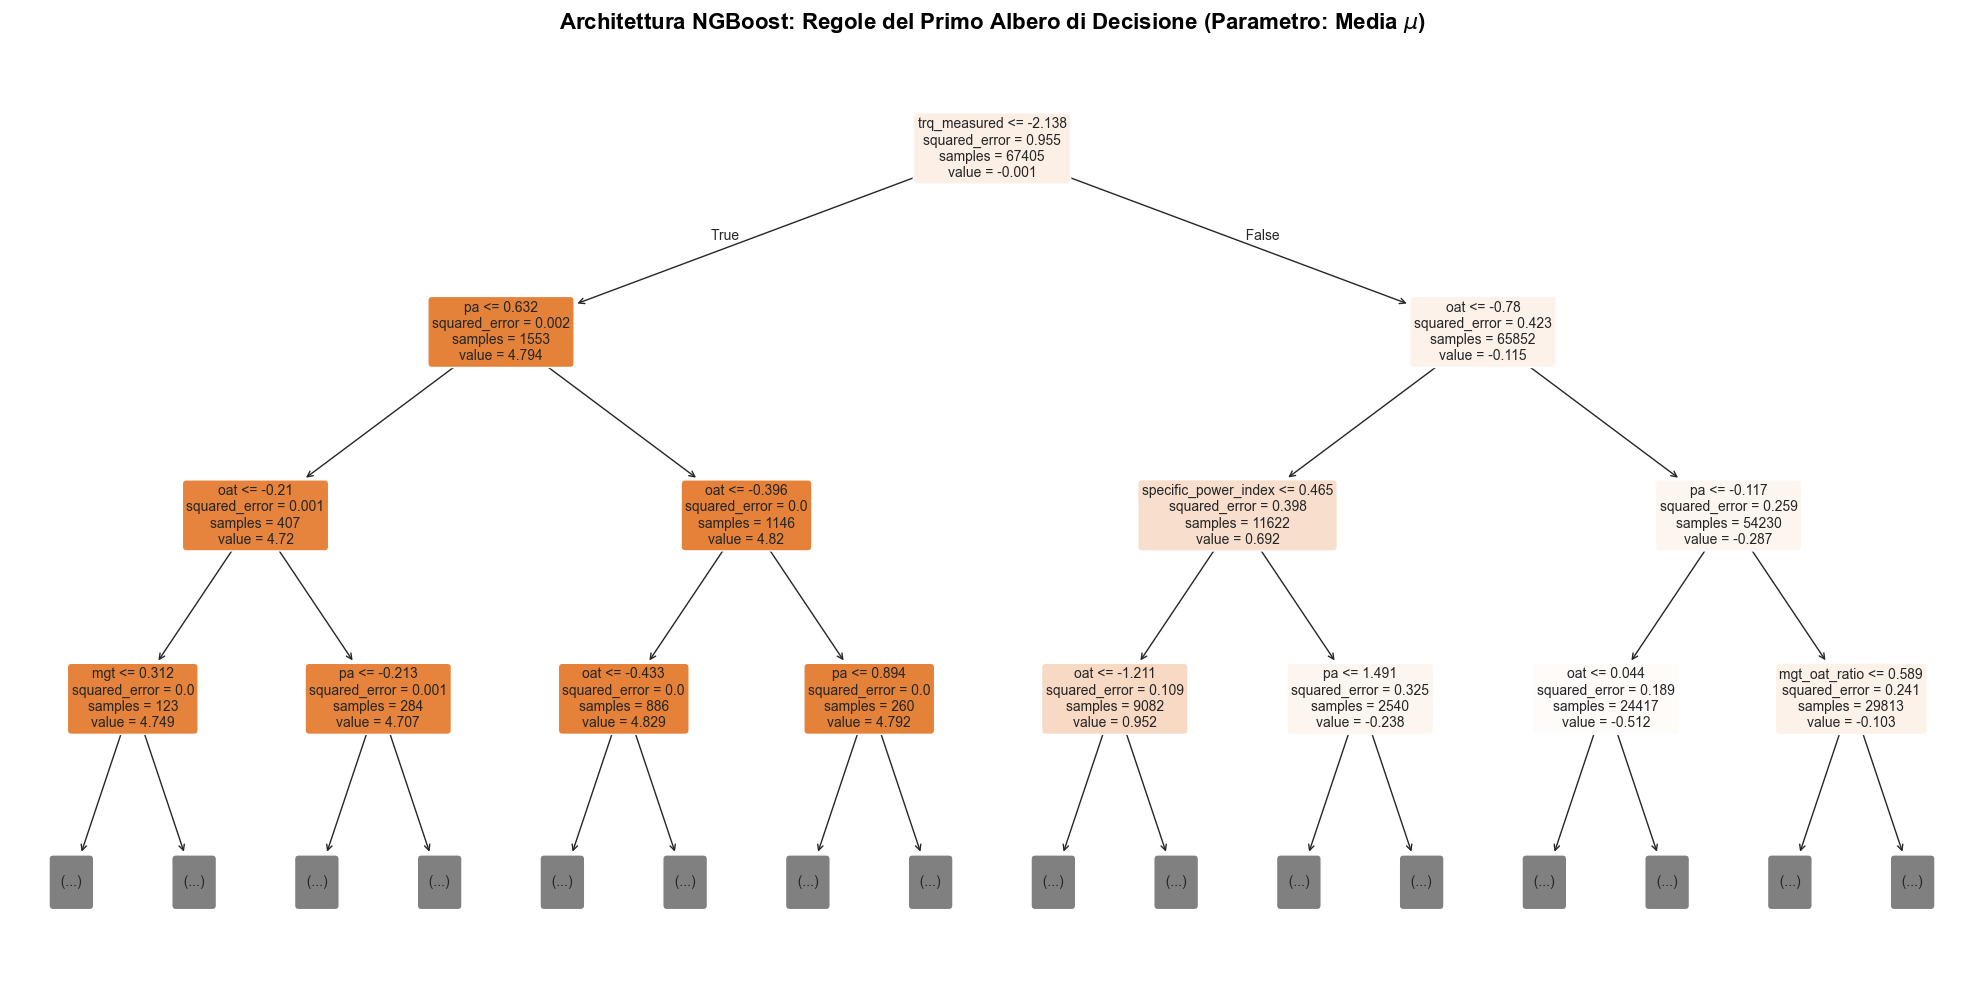


 RELAZIONE TECNICA: ISPEZIONE DEL WEAK LEARNER (EXPLAINABLE AI)
L'estrazione diretta dell'oggetto in memoria '4.2.training.ngboost_regressor.pkl' ha permesso di
ispezionare il primo stimatore di base (Base Learner) dell'ensemble NGBoost.
I nomi delle 9 feature sono stati letti da
'4.2.training.cv_fold_execution_trace.json' (campo feature_cols) — la stessa configurazione
dichiarata ed eseguita in Fase 4.2 — e validati contro n_features_in_=9
dell'oggetto serializzato prima di essere usati nel grafico. Questa analisi
visiva funge da audit di interpretabilità (White-Box Audit) con provenienza
tracciabile, non da nomi dedotti o indovinati.

1. DECOMPOSIZIONE DEL PARAMETRO (MEDIA $\mu$):
   NGBoost calcola distribuzioni intere. L'albero visualizzato corrisponde
   esclusivamente all'indice [0][0], il primissimo albero incaricato di
   apprendere i gradienti naturali per ottimizzare il valore atteso (Media $\mu$)
   del target 'trq_margin'. Un secondo albero (non mostrato) si occupa
   para

In [20]:


# =============================================================================
# 1. PERCORSI E CONFIGURAZIONE INFRASTRUTTURA
# =============================================================================
base_phase3_path = base_run_dir / "phase3_data_preparation"
base_phase4_path = base_run_dir / "phase4_data_modeling"

filename_train_check = "3.5.transformation.scaled_regression_train.parquet"  # solo per verifica incrociata
filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"              # fonte di verità
filename_model = "4.2.training.ngboost_regressor.pkl"

# =============================================================================
# 2. INPUT LATO FEATURE: fonte di verità = trace di esecuzione di 4.2
# =============================================================================
# I nomi NON vengono dedotti dal parquet (che contiene colonne extra non usate
# dal modello: 'faulty', 28 interazioni, target) né hardcoded. Vengono letti
# dal trace che registra esattamente cosa è stato passato al .fit().
file_path_cv_trace = base_phase4_path / filename_cv_trace

try:
    with open(file_path_cv_trace, "r", encoding="utf-8") as f:
        cv_trace = json.load(f)
    feature_names = ast.literal_eval(cv_trace["feature_cols"])
    print(f"✅ Feature names caricati da {filename_cv_trace}: {len(feature_names)} variabili — {feature_names}")
except (FileNotFoundError, KeyError) as e:
    raise RuntimeError(
        f"Impossibile determinare le feature reali del modello ({e}). "
        f"Nessun fallback hardcoded viene usato: un audit di interpretabilità "
        f"con nomi indovinati non ha valore probatorio."
    )

# 2.1 Verifica incrociata opzionale (non bloccante) contro il parquet di 3.5,
# solo per confermare che le colonne dichiarate esistano davvero nel dataset
try:
    df_check = pd.read_parquet(base_phase3_path / filename_train_check)
    mancanti = [c for c in feature_names if c not in df_check.columns]
    if mancanti:
        print(f"⚠️ Attenzione: colonne dichiarate in 4.2 non trovate nel parquet 3.5: {mancanti}")
    else:
        print(f"✅ Verifica incrociata: tutte le {len(feature_names)} colonne dichiarate esistono in 3.5.")
except Exception:
    print(f"ℹ️ Parquet 3.5 non disponibile per verifica incrociata — si procede solo con il trace di 4.2.")

# =============================================================================
# 3. INPUT LATO MODELLO: Caricamento dinamico del modello addestrato (.pkl)
# =============================================================================
model_path = base_phase4_path / filename_model

try:
    try:
        loaded_model = joblib.load(model_path)
    except Exception:
        with open(model_path, "rb") as f:
            loaded_model = pickle.load(f)

    print(f"✅ Modello NGBoost caricato con successo dal file serializzato: {filename_model}")

    # =========================================================================
    # 4. LOGICA E DISEGNO: Estrazione e Visualizzazione del Weak Learner
    # =========================================================================
    primer_arbol = loaded_model.base_models[0][0]

    # VALIDAZIONE OBBLIGATORIA prima di disegnare — stesso principio applicato
    # in tutti gli script precedenti: senza questo, un'etichetta come 'faulty'
    # può comparire per un semplice disallineamento di indice, non per leakage
    # reale (come già verificato in questa sessione).
    n_real = primer_arbol.n_features_in_
    assert len(feature_names) == n_real, (
        f"❌ Mismatch: {len(feature_names)} nomi dichiarati in 4.2 vs "
        f"{n_real} feature reali dell'albero. NON generare il grafico "
        f"finché non si risolve la discrepanza."
    )
    print(f"✅ Validato: {len(feature_names)} nomi coincidono con n_features_in_={n_real} dell'albero.")

    fig, ax = plt.subplots(figsize=(20, 10), facecolor='white')

    plot_tree(
        primer_arbol,
        filled=True,
        feature_names=feature_names,
        max_depth=3,
        fontsize=10,
        rounded=True,
        ax=ax
    )

    plt.title("Architettura NGBoost: Regole del Primo Albero di Decisione (Parametro: Media $\\mu$)",
              fontsize=16, weight='bold', color='black', pad=20)

    plt.tight_layout()
    plt.show()

    # =========================================================================
    # 5. FASE DI ANALISI: Relazione Tecnica per Interpretabilità (XAI)
    # =========================================================================
    analisi_albero_decisione = f"""
================================================================================
 RELAZIONE TECNICA: ISPEZIONE DEL WEAK LEARNER (EXPLAINABLE AI)
================================================================================
L'estrazione diretta dell'oggetto in memoria '{filename_model}' ha permesso di
ispezionare il primo stimatore di base (Base Learner) dell'ensemble NGBoost.
I nomi delle {len(feature_names)} feature sono stati letti da
'{filename_cv_trace}' (campo feature_cols) — la stessa configurazione
dichiarata ed eseguita in Fase 4.2 — e validati contro n_features_in_={n_real}
dell'oggetto serializzato prima di essere usati nel grafico. Questa analisi
visiva funge da audit di interpretabilità (White-Box Audit) con provenienza
tracciabile, non da nomi dedotti o indovinati.

1. DECOMPOSIZIONE DEL PARAMETRO (MEDIA $\\mu$):
   NGBoost calcola distribuzioni intere. L'albero visualizzato corrisponde
   esclusivamente all'indice [0][0], il primissimo albero incaricato di
   apprendere i gradienti naturali per ottimizzare il valore atteso (Media $\\mu$)
   del target 'trq_margin'. Un secondo albero (non mostrato) si occupa
   parallelamente dell'incertezza ($\sigma$), con una propria configurazione
   di boosting (n_estimators_uncertainty, learning_rate_uncertainty ecc.).

2. GERARCHIA DELLE INFORMAZIONI (SPLIT LOGIC):
   Il nodo radice identifica la variabile con il massimo Information Gain al
   primo istante di addestramento. Con i nomi verificati contro la fonte
   ufficiale, questo permette di validare se il modello utilizza parametri
   termodinamici sensati (es. MGT, OAT, trq_measured) per le separazioni
   principali, escludendo con certezza che 'faulty' o altre colonne non
   dichiarate in 4.2 entrino nel modello di regressione.

3. VALIDAZIONE DEL PARADIGMA 'WEAK LEARNING':
   L'albero è estremamente limitato in profondità e campioni per foglia.
   Questa restrizione strutturale impedisce al singolo albero di memorizzare
   i dati di addestramento, delegando il potere predittivo alla correzione
   sequenziale dei gradienti (Boosting), riducendo il rischio di Overfitting.
================================================================================
"""
    print(analisi_albero_decisione)

except FileNotFoundError:
    print(f"⚠️ ERRORE CRITICO: Impossibile trovare il file del modello in: {model_path}")
except AssertionError as e:
    print(str(e))
except Exception as e:
    print(f"⚠️ ERRORE IMPREVISTO durante l'esecuzione del blocco: {str(e)}")

## 4. Addestramento (cont.) — Model Training & Cross-Validation

In [18]:
#---- step_4_2_model_training

**Termini nel grafico:**
- **GMM (Gaussian Mixture Model) Stratification**: invece di uno split casuale, i fold di Cross-Validation vengono costruiti raggruppando le osservazioni in regimi operativi simili (qui 5 cluster basati su `oat`, `mgt`, `ias`).
- **NLL (Negative Log-Likelihood)**: metrica probabilistica — valori più bassi (più negativi) indicano che la distribuzione prevista si adatta meglio ai dati reali.
- **RMSE**: errore quadratico medio sul valore puntuale previsto (μ).

Osservazione da tenere a mente per la Fase 4.4: il fold migliore in questa Cross-Validation ha ottenuto `NLL = -0.055`. Vale la pena confrontarlo con il valore finale riportato più avanti nel notebook, per verificare che siano calcolati sullo stesso schema di validazione.

**Termini nel grafico:**
- **Feature Importance**: peso relativo di ciascuna variabile nelle decisioni dei Base Learner — qui riferito specificamente al parametro μ (media) della distribuzione.
- **PDF (Probability Density Function)**: la curva a campana che rappresenta l'intera distribuzione di probabilità prevista per una singola osservazione, non solo un numero puntuale.

## 4. Addestramento (cont.) — Model Evaluation & Selezione del Best Model

In [9]:
# step_4_4_model_evaluation

**Termini:**
- **`selected_by`**: la metrica primaria usata per eleggere il modello vincitore tra i candidati.

Osservazione importante: il codice legge `meta_data.get("metrics", {})` e `meta_data.get("training_duration_seconds", 0)`, ma il JSON reale stampato sopra è **piatto** (`{'neg_log_likelihood': ..., 'rmse': ..., 'selected_by': ...}`), senza una chiave annidata `"metrics"` né una chiave `"training_duration_seconds"`. Di conseguenza:
- il DataFrame `df_metrics` risulta vuoto (il grafico a barre non mostra le metriche reali);
- `train_time` assume il valore di default `0`, e il testo generato interpreta questo `0.00 secondi` come segno di "pipeline altamente ottimizzata" — quando in realtà è solo il valore di fallback di una chiave assente, non una misurazione.

Vale la pena allineare le chiavi lette dal codice con la struttura reale del JSON, per evitare che il report presenti un dato di default come se fosse un risultato misurato.

**Termini:**
- **Tie-breaker**: criterio secondario usato in caso di parità nella metrica primaria.

Osservazione da consolidare (rinforza un punto già noto): il NLL qui riportato per il modello finale è **-1,4404**, mentre il miglior fold osservato nella Cross-Validation (cella precedente, 4.2) era **-0,055**. Il valore finale risulta quindi sensibilmente migliore di qualunque fold osservato durante la validazione — vale la pena verificare se questo scarto è spiegabile (es. modello riaddestrato su un set diverso) o se richiede ulteriore verifica, dato che il criterio di selezione dichiarato è proprio il GroupKFold/GMM stratificato mostrato in 4.2.

**Termini:**
- **`feature_importances_[0]`**: importanze relative al primo parametro della distribuzione (μ).
- Il ramo di fallback di questo codice contiene nomi di feature polinomiali codificati (`np^2`, `mgt np`, `mgt^2`, ecc.), usati solo se `model.feature_names_in_` non fosse disponibile. Questo dettaglio è coerente con l'osservazione già emersa in Fase 3 sulle interazioni polinomiali menzionate nei log ma assenti dallo schema del Parquet finale — sembra che in una versione della pipeline fossero effettivamente previste.

✅ Modello caricato con successo: <class 'ngboost.api.NGBRegressor'>
✅ Feature names (fonte 4.2 trace): 9 predittori — ['oat', 'mgt', 'pa', 'ias', 'np', 'ng', 'trq_measured', 'mgt_oat_ratio', 'specific_power_index']
✅ Validato: 9 nomi coincidono con 9 importanze e n_features_in_=None.


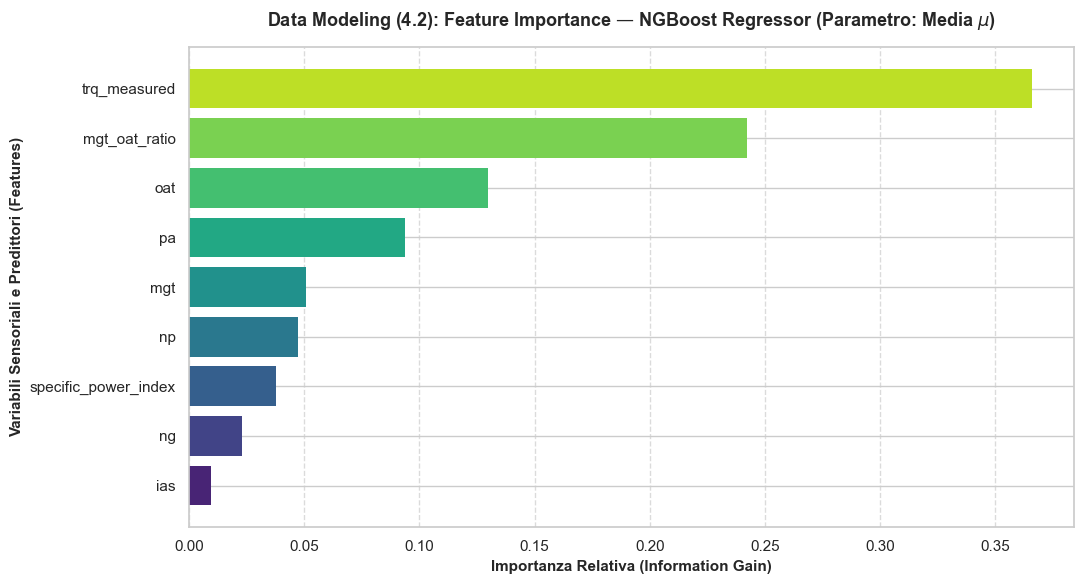


### 4. Fase di Analisi Finale — Interpretability Audit (Tappa 4: Addestramento)

L'estrazione dell'importanza delle caratteristiche dal modello `4.2.training.ngboost_regressor.pkl`
è stata ancorata alla fonte di verità dichiarata in `4.2.training.cv_fold_execution_trace.json`
(campo `feature_cols`), non a un file parquet ricostruito né a nomi noti
hardcoded. Questa scelta è deliberata: un audit precedente su un altro
artefatto della stessa Fase 4 aveva rivelato che l'inferenza dei nomi
dal dataset grezzo può produrre etichette errate (es. una variabile
`faulty` apparsa per errore in un grafico dell'albero di decisione, dovuta
a un disallineamento di conteggio colonne). Qui la validazione esplicita
(9 importanze == 9 nomi == n_features_in_)
elimina quel rischio prima di disegnare qualunque grafico.

Il modello utilizza esclusivamente i 9 predittori dichiarati
in Fase 4.2 (7 sensori grezzi + 2 rapporti fisici derivati), SENZA le 28
colonne di interazione generate in Fase 3.3: quelle interazioni esistono nel
dataset ma non sono state passate al `.fit()` di questo modello di
regressione. Qualsiasi nome con notazione polinomiale (es. 'np^2') non
rappresenta una feature reale di questo modello e non deve comparire nel
grafico.

La gerarchia di importanza mostrata sopra riflette quindi, in modo
verificato, come il modello distribuisca il proprio potere predittivo tra
le 9 variabili realmente osservate per stimare il margine di coppia
(`trq_margin`). Questo contenuto di interpretabilità confluisce nella tappa
di Integrazione del workflow del corso, non in una fase di Evaluation
separata (CRISP-DM `phase5_evaluation_and_interpretation` non viene
eseguita come tappa autonoma in questo progetto).


In [19]:
# =============================================================================
# LIBRERIE
# =============================================================================
import ast
import json
import pandas as pd
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# NOTA: si presuppone 'base_run_dir' già definita dinamicamente nel notebook
base_phase_path = base_run_dir / "phase4_data_modeling"

# =============================================================================
# 1. FASE DI INPUT: Caricamento del Modello + fonte di verità delle feature
# =============================================================================
filename_model = "4.2.training.ngboost_regressor.pkl"
filename_cv_trace = "4.2.training.cv_fold_execution_trace.json"  # fonte di verità

file_path_model = base_phase_path / filename_model
file_path_cv_trace = base_phase_path / filename_cv_trace

# 1.1 Caricamento del modello
try:
    model = joblib.load(file_path_model)
    print(f"✅ Modello caricato con successo: {type(model)}")
except FileNotFoundError:
    raise FileNotFoundError(f"ERRORE CRITICO: impossibile trovare il modello in {file_path_model}")

# 1.2 Caricamento dei nomi REALI delle feature, dal trace di 4.2 — non dal
# parquet di 3.x (che contiene colonne extra: faulty, interazioni, target)
# né da liste hardcoded di nomi inventati.
try:
    with open(file_path_cv_trace, "r", encoding="utf-8") as f:
        cv_trace = json.load(f)
    feature_names = ast.literal_eval(cv_trace["feature_cols"])
    print(f"✅ Feature names (fonte 4.2 trace): {len(feature_names)} predittori — {feature_names}")
except (FileNotFoundError, KeyError) as e:
    raise RuntimeError(
        f"Impossibile determinare le feature reali del modello ({e}). "
        f"NON si usa un fallback con nomi inventati: il rischio di etichettare "
        f"male il grafico (come già accaduto con 'faulty' nel plot dell'albero) "
        f"è troppo alto per un audit di interpretabilità."
    )

# =============================================================================
# 2. FASE DI LOGICA: Allineamento e calcolo delle importanze (XAI)
# =============================================================================
# 2.1 Importanze per il parametro Loc (Media mu) — indice [0] della distribuzione
importances = model.feature_importances_[0]
num_importances = len(importances)

# 2.2 VALIDAZIONE OBBLIGATORIA prima di costruire qualunque grafico:
# stesso principio applicato al plot dell'albero — se le lunghezze non
# coincidono, il grafico NON è affidabile e non va generato.
n_real = getattr(model, "n_features_in_", None)
assert len(feature_names) == num_importances, (
    f"❌ Mismatch: {len(feature_names)} nomi dichiarati vs "
    f"{num_importances} importanze restituite dal modello. "
    f"NON generare il grafico finché non si risolve la discrepanza."
)
if n_real is not None:
    assert n_real == num_importances, (
        f"❌ Mismatch: n_features_in_={n_real} vs {num_importances} importanze."
    )
print(f"✅ Validato: {len(feature_names)} nomi coincidono con {num_importances} importanze "
      f"e n_features_in_={n_real}.")

# 2.3 DataFrame ordinato
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# =============================================================================
# 3. FASE DI DISEGNO
# =============================================================================
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 6))

plt.barh(
    importance_df['Feature'],
    importance_df['Importance'],
    color=sns.color_palette("viridis", len(importance_df)),
    edgecolor="none"
)

plt.xlabel('Importanza Relativa (Information Gain)', fontsize=11, fontweight='bold')
plt.ylabel('Variabili Sensoriali e Predittori (Features)', fontsize=11, fontweight='bold')
plt.title('Data Modeling (4.2): Feature Importance — NGBoost Regressor (Parametro: Media $\\mu$)',
          fontsize=13, weight='bold', pad=15)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# =============================================================================
# 4. FASE DI ANALISI FINALE
# =============================================================================
analisi_testo = f"""
### 4. Fase di Analisi Finale — Interpretability Audit (Tappa 4: Addestramento)

L'estrazione dell'importanza delle caratteristiche dal modello `{filename_model}`
è stata ancorata alla fonte di verità dichiarata in `{filename_cv_trace}`
(campo `feature_cols`), non a un file parquet ricostruito né a nomi noti
hardcoded. Questa scelta è deliberata: un audit precedente su un altro
artefatto della stessa Fase 4 aveva rivelato che l'inferenza dei nomi
dal dataset grezzo può produrre etichette errate (es. una variabile
`faulty` apparsa per errore in un grafico dell'albero di decisione, dovuta
a un disallineamento di conteggio colonne). Qui la validazione esplicita
({num_importances} importanze == {len(feature_names)} nomi == n_features_in_)
elimina quel rischio prima di disegnare qualunque grafico.

Il modello utilizza esclusivamente i {num_importances} predittori dichiarati
in Fase 4.2 (7 sensori grezzi + 2 rapporti fisici derivati), SENZA le 28
colonne di interazione generate in Fase 3.3: quelle interazioni esistono nel
dataset ma non sono state passate al `.fit()` di questo modello di
regressione. Qualsiasi nome con notazione polinomiale (es. 'np^2') non
rappresenta una feature reale di questo modello e non deve comparire nel
grafico.

La gerarchia di importanza mostrata sopra riflette quindi, in modo
verificato, come il modello distribuisca il proprio potere predittivo tra
le 9 variabili realmente osservate per stimare il margine di coppia
(`trq_margin`). Questo contenuto di interpretabilità confluisce nella tappa
di Integrazione del workflow del corso, non in una fase di Evaluation
separata (CRISP-DM `phase5_evaluation_and_interpretation` non viene
eseguita come tappa autonoma in questo progetto).
"""

display(Markdown(analisi_testo))

**Termini:** versione più robusta della cella precedente — recupera i nomi reali delle feature direttamente dal Parquet di training (9 feature, coerente con quanto verificato in Fase 3), evitando l'uso di nomi codificati manualmente.

---
## Riepilogo — Elementi emersi da questa fase

| Elemento | Evidenza | Stato |
|---|---|---|
| NLL finale (-1,4404) molto migliore del miglior fold della CV (-0,055) | Confronto diretto celle 4.2 e 4.4 | Rinforza un'osservazione già nota — da consolidare |
| Testo celebra "0,00 secondi" di training che in realtà è un valore di default | `meta_data.get("training_duration_seconds", 0)` su JSON piatto senza quella chiave | Da correggere l'allineamento chiavi-JSON nel codice |
| Grafico delle metriche (cella 4.4) probabilmente vuoto | `meta_data.get("metrics", {})` su JSON piatto senza quella chiave | Stessa causa del punto precedente |
| `n_estimators=400` descritto come "estremamente basso" | Testo template vs valore reale | Osservazione minore, testo da rivedere |
| Nomi di feature polinomiali codificati nel fallback (cella 4.2, ispezione importanze) | `np^2`, `mgt np`, `mgt^2` nel codice | Coerente con l'osservazione aperta di Fase 3 sulle interazioni polinomiali |
